In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

In [ ]:
df = pd.read_csv("ecommerce_customer_churn_messy.csv")

df.head()

In [ ]:
df.shape

In [ ]:
df.columns.tolist()

In [ ]:
df.info()

In [ ]:
df.describe(include="all").T

In [ ]:
missing_summary = pd.DataFrame({
    "missing_count": df.isnull().sum(),
    "missing_percent": df.isnull().mean() * 100
})

missing_summary = missing_summary.sort_values(
    "missing_count",
    ascending=False
)

missing_summary

In [ ]:
missing_summary.head(5)

In [ ]:
df.duplicated().sum()

In [ ]:
df["churn"].value_counts(normalize=True) * 100

In [ ]:
df = df.drop_duplicates()

In [ ]:
df.shape

In [ ]:
missing_tokens = [
    "",
    "na",
    "n/a",
    "nan",
    "null",
    "none",
    "unknown",
    "?"
]

for col in df.select_dtypes(include=["object", "string"]).columns:
    df[col] = (
        df[col]
        .astype("string")
        .str.strip()
        .str.lower()
    )

    df[col] = df[col].replace(
        missing_tokens,
        np.nan
    )

In [ ]:
gender_map = {
    "female": "Female",
    "f": "Female",
    "male": "Male",
    "m": "Male"
}

df["gender"] = df["gender"].map(gender_map)

df["gender"].value_counts(dropna=False)

In [ ]:
membership_map = {
    "basic": "Basic",
    "premium": "Premium",
    "gold": "Gold",
    "platinum": "Platinum"
}

df["membership_type"] = (
    df["membership_type"]
    .map(membership_map)
)

df["membership_type"].value_counts(dropna=False)

In [ ]:
def parse_number(value):

    if pd.isna(value):
        return np.nan

    value = str(value).strip().lower()

    if value in [
        "",
        "na",
        "n/a",
        "nan",
        "null",
        "none",
        "unknown",
        "?",
        "-"
    ]:
        return np.nan

    value = value.replace(",", "")
    value = value.replace("$", "")
    value = value.replace("usd", "").strip()

    try:

        if value.endswith("k"):
            return float(value[:-1]) * 1_000

        if value.endswith("m"):
            return float(value[:-1]) * 1_000_000

        return float(value)

    except ValueError:
        return np.nan

In [ ]:
numeric_columns = [
    "customer_age",
    "annual_income",
    "account_balance",
    "total_spending",
    "average_order_value",
    "number_of_orders",
    "days_since_last_order",
    "website_visits",
    "support_tickets",
    "discount_usage",
    "refund_amount",
    "lifetime_value"
]

for col in numeric_columns:
    df[col] = df[col].apply(parse_number)

In [ ]:
df[numeric_columns].dtypes

In [ ]:
df.loc[
    ~df["customer_age"].between(18, 100),
    "customer_age"
] = np.nan

In [ ]:
non_negative_columns = [
    "annual_income",
    "total_spending",
    "average_order_value",
    "number_of_orders",
    "days_since_last_order",
    "website_visits",
    "support_tickets",
    "discount_usage",
    "refund_amount",
    "lifetime_value"
]

for col in non_negative_columns:
    df.loc[df[col] < 0, col] = np.nan

In [ ]:
date_columns = [
    "signup_date",
    "subscription_start",
    "subscription_end",
    "last_purchase_date",
    "last_login",
    "cancellation_date"
]

for col in date_columns:
    df[col] = pd.to_datetime(
        df[col],
        format="mixed",
        errors="coerce"
    )

In [ ]:
df[date_columns].isnull().sum()

In [ ]:
reference_date = pd.Timestamp("2025-07-01")

df["days_since_login"] = (
    reference_date - df["last_login"]
).dt.days

df["days_since_purchase"] = (
    reference_date - df["last_purchase_date"]
).dt.days

df["customer_tenure_days"] = (
    reference_date - df["signup_date"]
).dt.days

df["subscription_duration_days"] = (
    df["subscription_end"]
    - df["subscription_start"]
).dt.days

In [ ]:
df["orders_per_visit"] = (
    df["number_of_orders"] /
    df["website_visits"].replace(0, np.nan)
)

df["spending_per_order"] = (
    df["total_spending"] /
    df["number_of_orders"].replace(0, np.nan)
)

df["refund_rate"] = (
    df["refund_amount"] /
    df["total_spending"].replace(0, np.nan)
)

df["support_tickets_per_order"] = (
    df["support_tickets"] /
    df["number_of_orders"].replace(0, np.nan)
)

In [ ]:
leakage_columns = [
    "cancellation_reason",
    "cancellation_date",
    "final_account_status"
]

df = df.drop(
    columns=leakage_columns
)

In [ ]:
df = df.drop(
    columns=["customer_id"]
)

In [ ]:
raw_date_columns = [
    "signup_date",
    "subscription_start",
    "subscription_end",
    "last_purchase_date",
    "last_login"
]

df = df.drop(
    columns=raw_date_columns
)

In [ ]:
df.shape

In [ ]:
df.columns.tolist()

In [ ]:
df.dtypes

In [ ]:
missing_summary = pd.DataFrame({
    "missing_count": df.isnull().sum(),
    "missing_percent": df.isnull().mean() * 100
}).sort_values(
    "missing_count",
    ascending=False
)

missing_summary

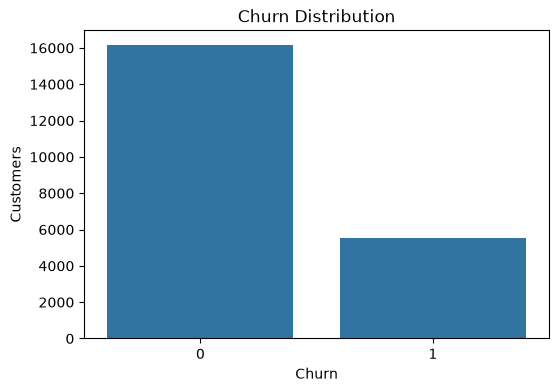

In [48]:
plt.figure(figsize=(6, 4))

sns.countplot(
    data=df,
    x="churn"
)

plt.title("Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Customers")

plt.show()

In [49]:
df.to_csv("Clearned_Data.csv",index=False)